# Week 3 Notebook 2: The first ten minutes with any dataset

**CSC: Data Analytics, Data Mining and Machine Learning**

Every dataset you meet gets the same opening routine. Before modelling or answering a research question, first learn what you actually have.

### Today’s routine
**Size -> rows -> column types -> missing values -> duplicates -> numerical summaries -> distributions -> relationships**

The examples use the Palmer Penguins dataset because it is small, real, and contains common data-quality issues.

## Setup

In [2]:
# pandas: tables and data cleaning; numpy: numerical operations.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display and chart defaults for the rest of the notebook.
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

## Load the data

This notebook uses the **Palmer Penguins** dataset: 344 penguins measured at Palmer Station, Antarctica. It is small, real, and messy in all the usual ways.

Your group's data may not be a CSV file. Pandas can read several common table formats. Choose the reader that matches the file you have:

| File type | Pandas reader |
| --- | --- |
| CSV | `pd.read_csv(...)` |
| TSV or other separated text | `pd.read_csv(..., sep="\t")` |
| Excel | `pd.read_excel(...)` |
| JSON | `pd.read_json(...)` |
| Parquet | `pd.read_parquet(...)` |

Run the penguins example first. Then replace `file_path` and uncomment one alternative reader for your own data. Excel and Parquet files may need an additional package installed in your Python environment.

In [3]:
# Load the file into a pandas DataFrame called df.
file_path = "../data/penguins.csv"
df = pd.read_csv(file_path)

# For another file, replace file_path and use the matching reader:
# df = pd.read_csv("../data/your_file.tsv", sep="\t")
# df = pd.read_excel("../data/your_file.xlsx")
# df = pd.read_json("../data/your_file.json")
# df = pd.read_parquet("../data/your_file.parquet")

# Preview the first five rows to check that the file loaded as expected.
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


---
## Move 1: How big is it?

Start with the number of **rows and columns**. If the size surprises you, stop and find out why.

In [4]:
# shape returns (number_of_rows, number_of_columns).
print("rows, columns:", df.shape)

rows, columns: (344, 7)


## Move 2: What does a row look like?

Look at a few rows. This helps you understand what one observation represents and whether the values look sensible.

In [5]:
# head() shows the first five rows of the table.
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Move 3: What type is each column?

The single most common data bug: a number stored as text. Use `.info()` to check the data types and whether columns contain missing values.

In [6]:
# info() shows column names, data types, and non-missing value counts.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


## Move 4: What is missing?

Counts tell you how much is missing; percentages make it easier to compare columns of different sizes.

Missing data is not automatically an error. First find out **where it is missing and why** before deciding what to do with it.

In [7]:
# Which rows have missing values, and are they concentrated in particular groups?
rows_with_missing = df[df.isna().any(axis=1)]
print("Rows with at least one missing value:", len(rows_with_missing))
display(rows_with_missing)

# Missing values broken down by species and island
print(df.drop(columns=["species"]).isna().groupby(df["species"]).sum())
print(df.drop(columns=["island"]).isna().groupby(df["island"]).sum())

Rows with at least one missing value: 11


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


           island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
species                                                               
Adelie          0               1              1                  1   
Chinstrap       0               0              0                  0   
Gentoo          0               1              1                  1   

           body_mass_g  sex  
species                      
Adelie               1    6  
Chinstrap            0    0  
Gentoo               1    5  
           species  bill_length_mm  bill_depth_mm  flipper_length_mm  \
island                                                                 
Biscoe           0               1              1                  1   
Dream            0               0              0                  0   
Torgersen        0               1              1                  1   

           body_mass_g  sex  
island                       
Biscoe               1    5  
Dream                0    1  
Torgersen    

### A question worth asking

**Answer: is missingness scattered or patterned?**
It is not scattered randomly.
- `sex` has by far the most missing values.
- Every measurement column (bill length, bill depth, flipper length, body mass) is missing for the same couple of penguins. Those birds were probably recorded but never measured, so it looks like a data-collection gap rather than random noise.

Because of this, dropping those rows removes a whole observation, not just one value. It is also worth checking whether missing `sex` is more common for some species or islands (table above) before deciding how to handle it.

---
## Move 5: Duplicates

Exact duplicate rows can indicate a data-processing problem. Check them before analysing the data.

In [8]:
# duplicated() marks rows that are exact copies of an earlier row.
# sum() counts how many duplicate rows were found.
print("exact duplicate rows:", df.duplicated().sum())

exact duplicate rows: 0


---
## Move 6: Summarise the numbers

`.describe()` gives count, mean, standard deviation, minimum, quartiles and maximum for numeric columns.

**Look at the minimum and maximum first.** They can reveal impossible or suspicious values before the average hides them.

In [9]:
# describe() calculates common summaries for numeric columns.
# Transpose so each variable appears as a row, which is easier to read.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
bill_length_mm,342.0,43.921930,5.459584,32.1,39.225,44.45,48.5,59.6
bill_depth_mm,342.0,17.151170,1.974793,13.1,15.600,17.30,18.7,21.5
flipper_length_mm,342.0,200.915205,14.061714,172.0,190.000,197.00,213.0,231.0
body_mass_g,342.0,4201.754386,801.954536,2700.0,3550.000,4050.00,4750.0,6300.0


---
## Move 7: Look at the distributions

Now connect this notebook to the previous one: use histograms to see the shape of every numeric variable.

Look for:
- skew
- multiple peaks
- gaps
- suspicious spikes
- values that look impossible

You do not need to interpret every detail yet. The goal is to notice what deserves a closer look.

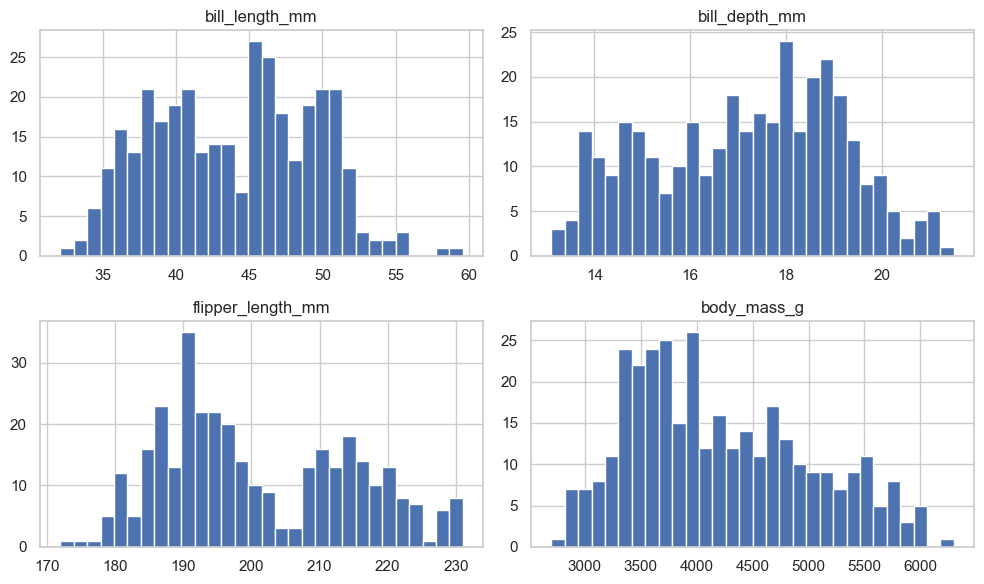

In [10]:
# Select numeric columns and draw one histogram for each.
df.select_dtypes("number").hist(figsize=(10, 6), bins=30, edgecolor="white")
plt.tight_layout()
plt.show()

### One thing to notice

Look at `bill_depth_mm`. It does not look like one simple hump. A distribution can contain multiple groups mixed together, which is one reason that **grouping variables matter**.

**Answer: why `bill_depth_mm` has two humps**
The histogram is bimodal because it mixes species. Gentoo penguins have shallower bills (about 13–17 mm), while Adelie and Chinstrap have deeper bills (about 16–21 mm). One variable is really two overlapping groups, so plotting by `species` separates them.

---
## Move 8: How do the numbers relate?

A correlation matrix is a fast first pass for numeric variables. In this notebook, pandas uses **Pearson correlation** by default. Pearson correlation measures the strength and direction of a **linear relationship**: whether larger values of one variable tend to occur with larger or smaller values of another variable in a roughly straight-line pattern.

Pearson correlation ranges from `-1` to `1`:

- `1` means a perfect positive linear relationship;
- `-1` means a perfect negative linear relationship; and
- `0` means no linear relationship.

A value near `0` does not prove that there is no relationship. A curved relationship can have a small Pearson correlation. Treat this matrix as a screening tool, then inspect a scatter plot.

Other correlation measures answer slightly different questions. **Spearman correlation** compares the ranks of values and is useful for a consistently increasing or decreasing relationship that is not straight. **Kendall correlation** also uses ranks and is often useful with smaller datasets or many tied values.

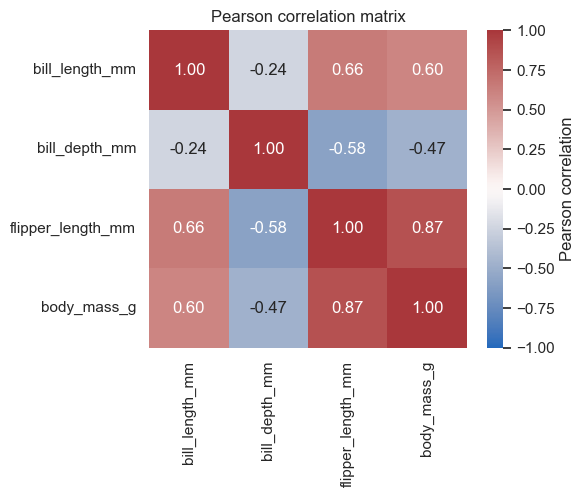

In [11]:
# Select numeric columns and calculate Pearson correlations.
# Pearson is pandas' default method and measures linear relationships.
numeric_data = df.select_dtypes("number")
corr = numeric_data.corr(method="pearson")

# A heatmap makes positive and negative relationships easier to scan.
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"label": "Pearson correlation"})
plt.title("Pearson correlation matrix")
plt.tight_layout()
plt.show()

## Check your understanding

Use the outputs above to answer these questions about the penguins dataset. Choose or calculate the answers in the next cell.

- How many rows are in the dataset?
- How many columns are in the dataset?
- Which column has the most missing values?
- How many exact duplicate rows are there?
- Which columns contain numeric measurements?

The final cell loads the external checker from the `tests/` folder and tells you whether your answers are correct.

**What the correlation matrix shows**
- `flipper_length_mm` and `body_mass_g` are strongly positively correlated (about 0.87): bigger penguins have longer flippers.
- `bill_length_mm` and `bill_depth_mm` have a weak negative correlation overall. Within each species, though, the relationship is positive (notebook 01). This is Simpson's paradox, and the reason to check groups before trusting an overall correlation.

In [15]:
number_of_rows = df.shape[0]
number_of_columns = df.shape[1]
column_with_most_missing = df.isna().sum().idxmax()
duplicate_rows = int(df.duplicated().sum())

# Numeric measurements; 'year' (if present) is a date label, not a measurement.
numeric_columns = [c for c in df.select_dtypes("number").columns if c != "year"]

print(number_of_rows, number_of_columns)
print(column_with_most_missing, duplicate_rows)
print(numeric_columns)

344 7
sex 0
['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']


Run the next cell after filling in your answers. It imports the external test from `tests/` and reports the result without showing the expected answers.

In [16]:
from pathlib import Path
import sys
import importlib

project_root = Path.cwd()
if not (project_root / "tests").is_dir():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import tests.test_first_look as first_look_tests
importlib.reload(first_look_tests)

check_passed = first_look_tests.check_first_look(globals())
print("Passed" if check_passed else "Not passed yet")

Dataset inspection checks passed!
Passed


---
## Your turn

Take a few minutes to inspect this dataset. Write three short observations:

1. **One thing that surprised you**
2. **One thing that looks potentially wrong or worth checking**
3. **One question you would investigate next**

The aim is not to “solve” the dataset. Good exploratory analysis produces better questions.

In [14]:
# Your three sentences here (as a comment or a markdown cell: your choice)

**My three observations**

1. **Surprised me:** overall, longer bills are *less* deep (weak negative correlation), yet within every species longer bills are *deeper*. Mixing species reverses the relationship.
2. **Worth checking:** `sex` has the most missing values, and a couple of penguins have no measurements at all. I would also check `df["sex"].value_counts(dropna=False)` for inconsistent labels (e.g. "MALE" vs "Male" or a stray ".").
3. **Next question:** does the strong flipper length–body mass relationship hold within each species and sex, or is it mostly driven by Gentoo penguins being larger than the other two species?

## The routine to remember

Use this order when you receive a new dataset:

**How big is it? -> What is one row? -> What are the columns? -> What is missing? -> Are there duplicates? -> What do the numbers look like? -> What relationships are visible?**

Only after this first look should you start making stronger decisions about cleaning, modelling, or statistical analysis.